Train: (350000, 38), Val: (75000, 38), Test: (75000, 38)
Class weights: {np.int64(0): np.float64(18.56370001060783), np.int64(1): np.float64(0.5138399109735652)}

Training Logistic Regression...


C:\Users\CyrilCorp\PyCharmMiscProject\ids-iiot-deeplearning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Done.

Validation:
  F1:        0.9941
  AUC-ROC:   0.9977
  Precision: 0.9999
  Recall:    0.9885
  Accuracy:  0.9887

Test:
  F1:        0.9942
  AUC-ROC:   0.9979
  Precision: 0.9999
  Recall:    0.9885
  Accuracy:  0.9887


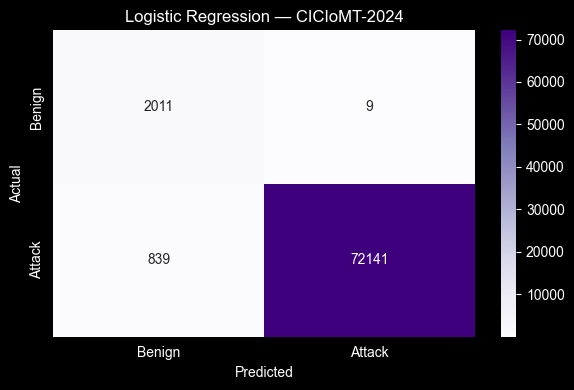


TN: 2011  FP: 9  FN: 839  TP: 72141
Model saved.


In [1]:
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

PROCESSED = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\data\processed"
RESULTS   = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\results"
MODELS    = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\models"

X_train = np.load(os.path.join(PROCESSED, "ciciomt2024_X_train.npy"))
X_val   = np.load(os.path.join(PROCESSED, "ciciomt2024_X_val.npy"))
X_test  = np.load(os.path.join(PROCESSED, "ciciomt2024_X_test.npy"))
y_train = np.load(os.path.join(PROCESSED, "ciciomt2024_y_train.npy"))
y_val   = np.load(os.path.join(PROCESSED, "ciciomt2024_y_val.npy"))
y_test  = np.load(os.path.join(PROCESSED, "ciciomt2024_y_test.npy"))
class_weights = joblib.load(os.path.join(PROCESSED, "ciciomt2024_class_weights.pkl"))

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Class weights: {class_weights}")

# Train
print("\nTraining Logistic Regression...")
lr = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000,
                        class_weight=class_weights, random_state=42, n_jobs=-1)
lr.fit(X_train, y_train)
print("Done.")

# Evaluate
def evaluate(model, X, y, name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    print(f"\n{name}:")
    print(f"  F1:        {f1_score(y, y_pred):.4f}")
    print(f"  AUC-ROC:   {roc_auc_score(y, y_prob):.4f}")
    print(f"  Precision: {precision_score(y, y_pred):.4f}")
    print(f"  Recall:    {recall_score(y, y_pred):.4f}")
    print(f"  Accuracy:  {accuracy_score(y, y_pred):.4f}")
    return model.predict(X), model.predict_proba(X)[:, 1]

evaluate(lr, X_val,  y_val,  "Validation")
evaluate(lr, X_test, y_test, "Test")

# Confusion matrix
y_pred_test = lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
plt.title('Logistic Regression — CICIoMT-2024', fontsize=12)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "ciciomt2024_lr_confusion_matrix.png"), dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTN: {tn}  FP: {fp}  FN: {fn}  TP: {tp}")

joblib.dump(lr, os.path.join(MODELS, "ciciomt2024_logistic_regression.pkl"))
print("Model saved.")